In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

In [3]:
df = pd.read_csv("../raw/fraudTrain.csv", parse_dates = ["trans_date_trans_time", "dob"], dtype = {"cc_num": "string", "trans_num": "string", "zip": "string"})

In [6]:
# Removendo a coluna de índice
colunas_sem_nome = [coluna for coluna in df.columns if coluna.startswith("Unnamed")]

df = df.drop(columns=colunas_sem_nome)

In [8]:
# Ordenando de maneira cronológica
df = (df.sort_values("trans_date_trans_time").reset_index(drop = True))

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Início: {df['trans_date_trans_time'].min()}")
print(f"Fim: {df['trans_date_trans_time'].max()}")

Linhas: 1,296,675
Colunas: 22
Início: 2019-01-01 00:00:18
Fim: 2020-06-21 12:13:37


In [9]:
def calcular_distancia_km(
        lat_cliente: pd.Series,
        lon_cliente: pd.Series,
        lat_estabelecimento: pd.Series,
        lon_estabelecimento: pd.Series
) -> np.ndarray:
    """
    Calcula a distancia entre dois pontos geográficos utilizando a fórmula de Haversine.
    """

    raio_terra_km = 6371.0088

    lat1 = np.radians(lat_cliente.to_numpy())
    lon1 = np.radians(lon_cliente.to_numpy())
    lat2 = np.radians(lat_estabelecimento.to_numpy())
    lon2 = np.radians(lon_estabelecimento.to_numpy())

    delta_lat = lat2 - lat1
    delta_lon  = lon2 - lon1

    a = (np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2 )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return raio_terra_km * c

In [24]:
def criar_features(dados: pd.DataFrame) -> pd.DataFrame:
    """
    Cria as variáveis utilizadas pela Regressão Logística.
    
    Todas as variáveis são construídas usando apenas informações da própria transação.
    """

    features = pd.DataFrame(index = dados.index)

    data_transacao = dados["trans_date_trans_time"]
    data_nascimento = dados["dob"]

    # Valor da transação em escala logarítmica
    features["amt_log"] = np.log1p(dados["amt"])

    # População também apresenta assimetria
    features["city_pop_log"] = np.log1p(dados["city_pop"])

    # Idade exata na data da transação
    aniversario_ainda_nao_ocorreu = (data_transacao.dt.month < data_nascimento.dt.month) | ((data_transacao.dt.month == data_nascimento.dt.month) & (data_transacao.dt.day < data_nascimento.dt.day))

    features["idade"] = (
        data_transacao.dt.year - data_nascimento.dt.year - aniversario_ainda_nao_ocorreu.astype(int)
    )

    # Distância aproximada entre cliente e estabelecimento
    features["distancia_km"] = calcular_distancia_km(
        dados["lat"],
        dados["long"],
        dados["merch_lat"],
        dados["merch_long"]
    )

    # Variáveis temporais cíclicas
    hora = data_transacao.dt.hour

    features["hora_sin"] = np.sin(
        2 * np.pi * hora / 24
    )

    features["hora_cos"] = np.cos(
        2 * np.pi * hora / 24
    )

    dia_semana = data_transacao.dt.dayofweek

    features["dia_semana_sin"] = np.sin(
        2 * np.pi * dia_semana / 7
    )
    
    features["dia_semana_cos"] = np.cos(
        2 * np.pi * dia_semana / 7
    )

    features["fim_de_semana"] = (
        dia_semana >= 5
    ).astype(int)

    # variáveis categóricas
    features["category"] = dados["category"].astype("string")
    features["gender"] = dados["gender"].astype("string")
    features["state"] = dados["state"].astype("string")

    return features

In [25]:
# Separação temporal
# 70% dos dados mais antigos -> treino
# 15% seguinte -> validação
# 15% mais recente -> teste

limite_treino = int(len(df) * 0.7)
limite_validacao = int(len(df) * 0.85)

df_treino = df.iloc[:limite_treino].copy()

df_validacao = df.iloc[limite_treino:limite_validacao].copy()

df_teste = df.iloc[limite_validacao:].copy()

In [26]:
# criando as features
X_treino = criar_features(df_treino)
X_validacao = criar_features(df_validacao)
X_teste = criar_features(df_teste)

y_treino = df_treino["is_fraud"].astype(int)
y_validacao = df_validacao["is_fraud"].astype(int)
y_teste = df_teste["is_fraud"].astype(int)

In [27]:
def resumo_particao(nome: str, dados: pd.DataFrame, target: pd.Series) -> dict:
    return {
        "particao": nome,
        "inicio": dados["trans_date_trans_time"].min(), 
        "fim": dados["trans_date_trans_time"].max(),
        "transacoes": len(dados),
        "fraudes": int(target.sum()),
        "taxa_fraude_percentual": target.mean() * 100
    }

resumo_particoes = pd.DataFrame([
    resumo_particao("Treino", df_treino, y_treino),
    resumo_particao("Validação", df_validacao, y_validacao),
    resumo_particao("Teste", df_teste, y_teste)
])

In [28]:
resumo_particoes

,particao,inicio,fim,transacoes,fraudes,taxa_fraude_percentual
0,Treino,2019-01-01 00:00:18,2019-12-28 17:18:24,907672,5121,0.564191
1,Validação,2019-12-28 17:18:38,2020-04-03 17:53:52,194501,1252,0.643698
2,Teste,2020-04-03 17:54:44,2020-06-21 12:13:37,194502,1133,0.582513


In [29]:
# variaveis que serão utilizadas

variaveis_numericas = [
    "amt_log",
    "city_pop_log",
    "idade",
    "distancia_km",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "fim_de_semana"
]

variaveis_categoricas = [
   "category",
   "gender",
   "state"
]

In [30]:
# Tratando variaveis númericas
pipeline_numericas = Pipeline(
    steps = [
        (
            "preencher_nulos",
            SimpleImputer(strategy = "median")
        ),
        (
            "padronizar",
            StandardScaler()
        )
    ]
)

In [31]:
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown = "ignore",
        sparse_output = False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown = "ignore",
        sparse = False
    )

In [32]:
pipeline_categoricas = Pipeline(
    steps = [
        (
            "preencher_nulos",
            SimpleImputer(strategy = "most_frequent")
        ),
        (
            "one_hot",
            one_hot_encoder
        )
    ]
)

In [33]:
preprocessamento = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numericas,
            variaveis_numericas
        ),
        (
            "categoricas",
            pipeline_categoricas,
            variaveis_categoricas
        )
    ]
)

In [34]:
regressao_logistica = LogisticRegression(
    solver = "saga",
    class_weight = "balanced",
    C = 1.0,
    max_iter = 500,
    random_state = 42
)

In [35]:
modelo = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessamento
        ),
        (
            "classificador",
            regressao_logistica
        )
    ]
)

modelo

,steps,"[('preprocessamento', ...), ('classificador', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
X_treino

,amt_log,city_pop_log,idade,distancia_km,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,fim_de_semana,category,gender,state
0,1.786747,8.159375,30,78.597677,0.000000,1.000000,0.781831,0.623490,0,misc_net,F,NC
1,4.684259,5.010635,40,30.212217,0.000000,1.000000,0.781831,0.623490,0,grocery_pos,F,WA
2,5.398660,8.332068,56,108.206232,0.000000,1.000000,0.781831,0.623490,0,entertainment,M,ID
3,3.828641,7.570443,51,95.673363,0.000000,1.000000,0.781831,0.623490,0,gas_transport,M,MT
4,3.760269,4.605170,32,77.556851,0.000000,1.000000,0.781831,0.623490,0,misc_pos,M,VA
...,...,...,...,...,...,...,...,...,...,...,...,...
907667,4.215972,10.664714,37,82.676809,-0.965926,-0.258819,-0.974928,-0.222521,1,home,F,OR
907668,4.189655,11.662689,36,127.608274,-0.965926,-0.258819,-0.974928,-0.222521,1,health_fitness,F,VA
907669,1.961502,7.218177,79,93.708199,-0.965926,-0.258819,-0.974928,-0.222521,1,entertainment,F,VA
907670,3.476614,5.921578,24,126.410788,-0.965926,-0.258819,-0.974928,-0.222521,1,entertainment,F,MI


In [37]:
inicio_treinamento = perf_counter()

modelo.fit(
    X_treino,
    y_treino
)

tempo_treinamento = (
    perf_counter()
    - inicio_treinamento
)

print(
    f"Tempo de treinamento: "
    f"{tempo_treinamento:.2f} segundos"
)

Tempo de treinamento: 536.25 segundos


/home/lucas/Documentos/tcc_ccard_fraud/venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [38]:
numero_iteracoes = (
    modelo
    .named_steps["classificador"]
    .n_iter_[0]
)

print(f"Número de iterações: {numero_iteracoes}")

Número de iterações: 500


In [39]:
scores_validacao = modelo.predict_proba(
    X_validacao
)[:, 1]

In [40]:
pd.Series(scores_validacao).describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99,
        0.999
    ]
)

count    1.945010e+05
mean     2.196207e-01
std      3.952763e-01
min      3.438720e-41
50%      1.672803e-07
90%      9.999341e-01
95%      9.999999e-01
99%      1.000000e+00
99.9%    1.000000e+00
max      1.000000e+00
dtype: float64

In [41]:
threshold_inicial = 0.50

previsoes_validacao = (
    scores_validacao >= threshold_inicial
).astype(int)

In [42]:
def avaliar_modelo(
    y_real: pd.Series,
    scores: np.ndarray,
    threshold: float
) -> pd.DataFrame:
    previsoes = (
        scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        previsoes
    ).ravel()

    metricas = {
        "threshold": threshold,
        "average_precision": average_precision_score(
            y_real,
            scores
        ),
        "roc_auc": roc_auc_score(
            y_real,
            scores
        ),
        "accuracy": accuracy_score(
            y_real,
            previsoes
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_real,
            previsoes
        ),
        "precision_fraude": precision_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "recall_fraude": recall_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "f1_fraude": f1_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "verdadeiros_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiros_positivos": tp,
        "percentual_alertado": previsoes.mean() * 100
    }

    return pd.DataFrame(
        [metricas]
    )

In [43]:
resultado_threshold_05 = avaliar_modelo(
    y_validacao,
    scores_validacao,
    threshold=0.50
)

resultado_threshold_05.T

,0
threshold,0.500000
average_precision,0.079519
roc_auc,0.832458
accuracy,0.783780
balanced_accuracy,0.749541
precision_fraude,0.021013
recall_fraude,0.714856
f1_fraude,0.040826
verdadeiros_negativos,151551.000000
falsos_positivos,41698.000000


In [44]:
print(
    classification_report(
        y_validacao,
        previsoes_validacao,
        target_names=[
            "Legítima",
            "Fraude"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Legítima     0.9976    0.7842    0.8782    193249
      Fraude     0.0210    0.7149    0.0408      1252

    accuracy                         0.7838    194501
   macro avg     0.5093    0.7495    0.4595    194501
weighted avg     0.9914    0.7838    0.8728    194501



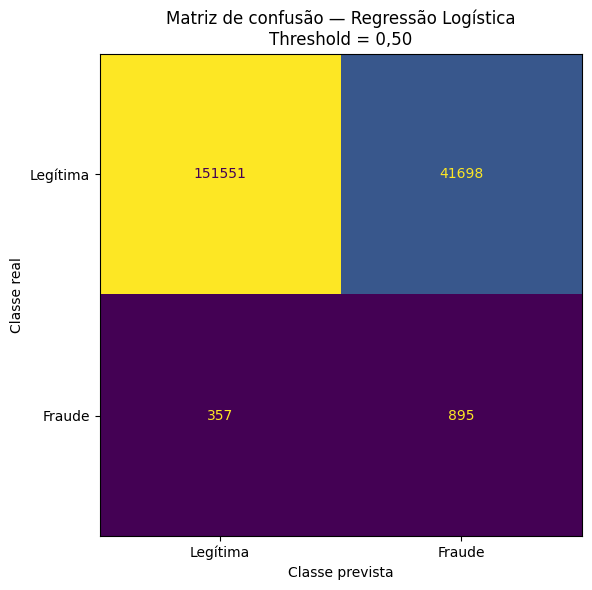

In [45]:
matriz = confusion_matrix(
    y_validacao,
    previsoes_validacao
)

fig, ax = plt.subplots(figsize=(7, 6))

visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=[
        "Legítima",
        "Fraude"
    ]
)

visualizacao.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusão — Regressão Logística\n"
    "Threshold = 0,50"
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

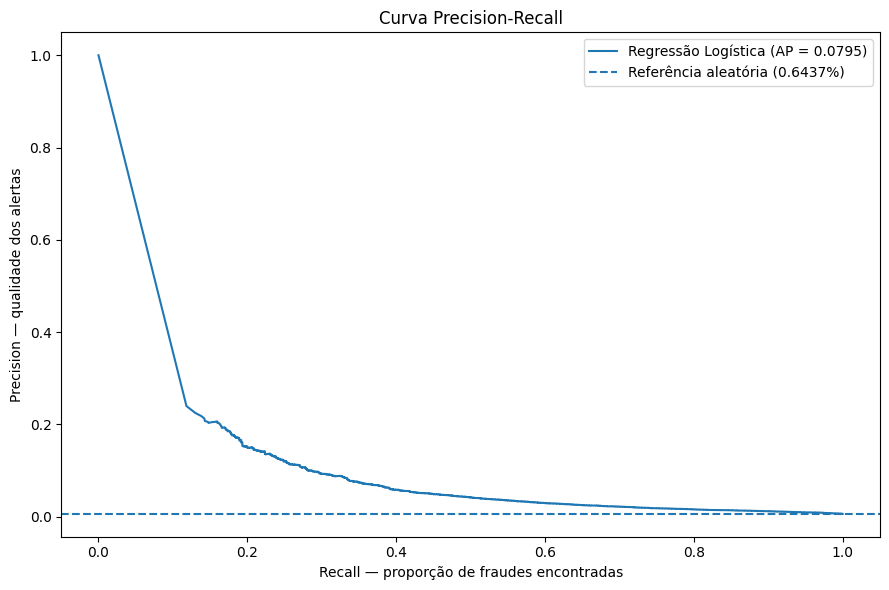

In [46]:
precision, recall, thresholds = precision_recall_curve(
    y_validacao,
    scores_validacao
)

average_precision = average_precision_score(
    y_validacao,
    scores_validacao
)

prevalencia_fraude = y_validacao.mean()

plt.figure(figsize=(9, 6))

plt.plot(
    recall,
    precision,
    label=(
        "Regressão Logística "
        f"(AP = {average_precision:.4f})"
    )
)

plt.axhline(
    prevalencia_fraude,
    linestyle="--",
    label=(
        "Referência aleatória "
        f"({prevalencia_fraude:.4%})"
    )
)

plt.title("Curva Precision-Recall")
plt.xlabel("Recall — proporção de fraudes encontradas")
plt.ylabel("Precision — qualidade dos alertas")
plt.legend()

plt.tight_layout()
plt.show()

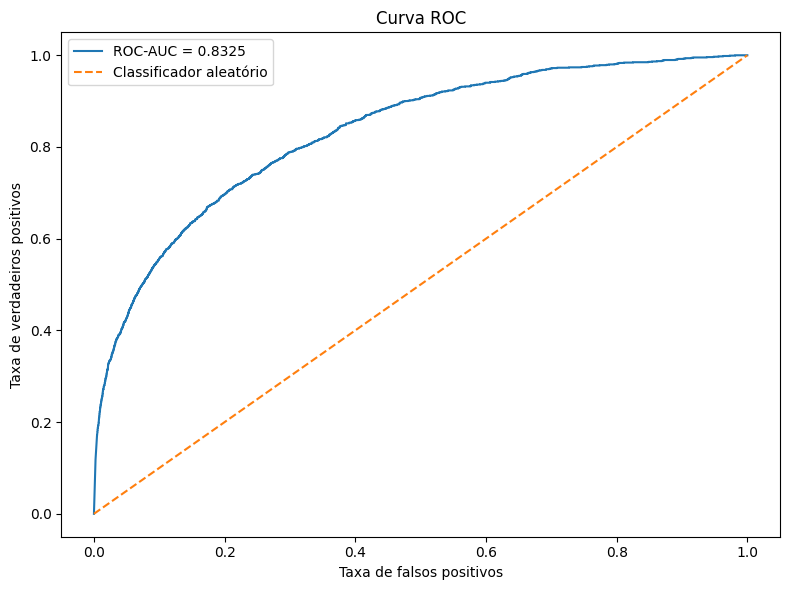

In [47]:
fpr, tpr, thresholds_roc = roc_curve(
    y_validacao,
    scores_validacao
)

roc_auc = roc_auc_score(
    y_validacao,
    scores_validacao
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.title("Curva ROC")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()

plt.tight_layout()
plt.show()

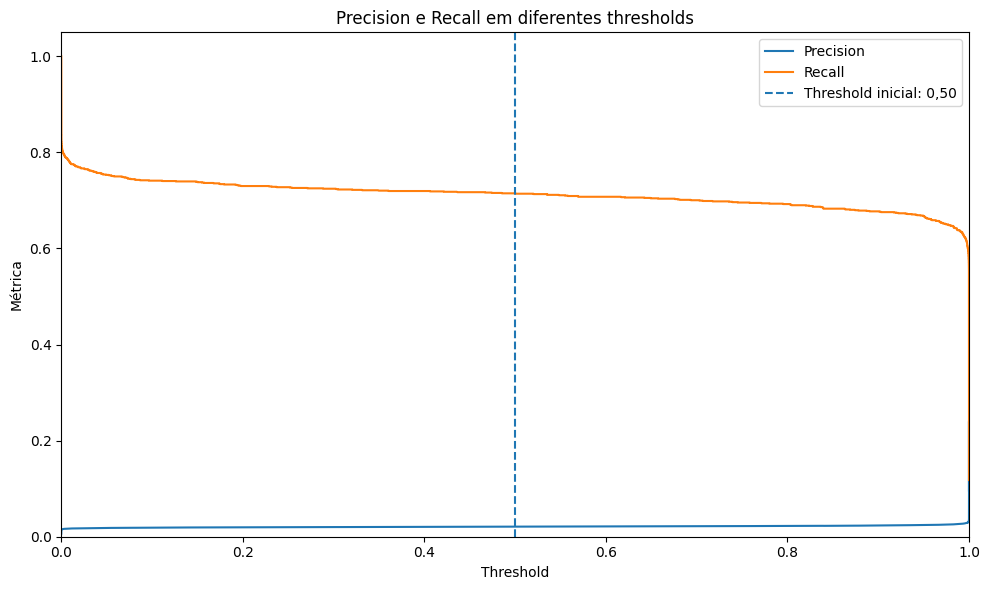

In [48]:
precision_threshold = precision[:-1]
recall_threshold = recall[:-1]

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision_threshold,
    label="Precision"
)

plt.plot(
    thresholds,
    recall_threshold,
    label="Recall"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Threshold inicial: 0,50"
)

plt.title("Precision e Recall em diferentes thresholds")
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

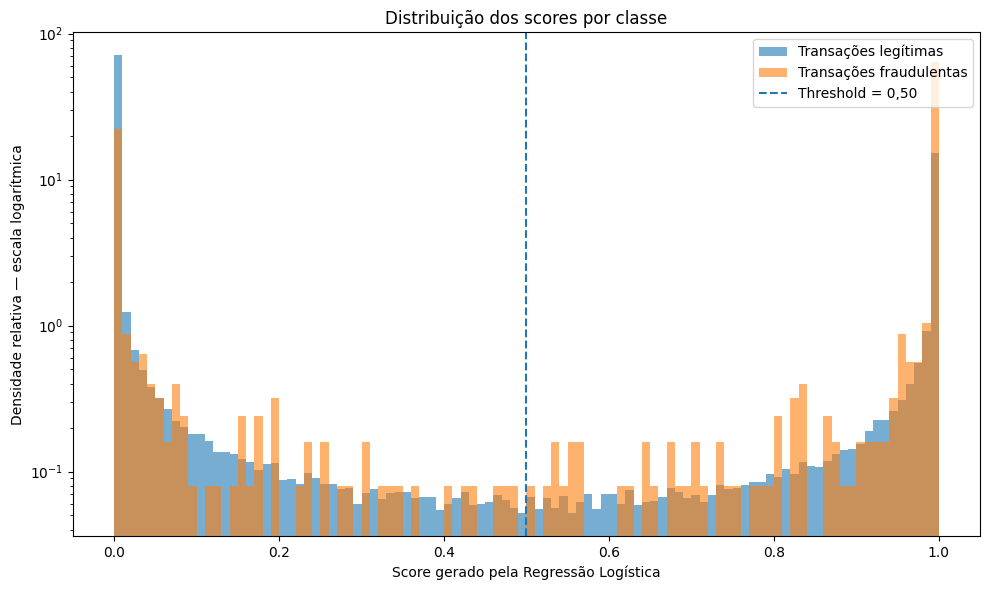

In [49]:
scores_legitimas = scores_validacao[
    y_validacao.to_numpy() == 0
]

scores_fraudes = scores_validacao[
    y_validacao.to_numpy() == 1
]

plt.figure(figsize=(10, 6))

plt.hist(
    scores_legitimas,
    bins=100,
    density=True,
    alpha=0.6,
    label="Transações legítimas"
)

plt.hist(
    scores_fraudes,
    bins=100,
    density=True,
    alpha=0.6,
    label="Transações fraudulentas"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Threshold = 0,50"
)

plt.yscale("log")

plt.title("Distribuição dos scores por classe")
plt.xlabel("Score gerado pela Regressão Logística")
plt.ylabel("Densidade relativa — escala logarítmica")
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
nomes_features = (
    modelo
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

coeficientes = (
    modelo
    .named_steps["classificador"]
    .coef_[0]
)

tabela_coeficientes = pd.DataFrame({
    "variavel": nomes_features,
    "coeficiente": coeficientes
})

tabela_coeficientes["variavel"] = (
    tabela_coeficientes["variavel"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)

tabela_coeficientes["coeficiente_absoluto"] = (
    tabela_coeficientes["coeficiente"].abs()
)

tabela_coeficientes = (
    tabela_coeficientes
    .sort_values(
        "coeficiente_absoluto",
        ascending=False
    )
)

tabela_coeficientes.head(20)

,variavel,coeficiente,coeficiente_absoluto
33,state_DE,31.171364,31.171364
10,category_food_dining,-16.784108,16.784108
22,category_travel,16.636291,16.636291
64,state_RI,13.811367,13.811367
31,state_CT,-13.721106,13.721106
40,state_IN,-11.838602,11.838602
4,hora_sin,-10.673093,10.673093
5,hora_cos,9.567157,9.567157
15,category_home,-9.541795,9.541795
28,state_AZ,-9.435256,9.435256


In [51]:
maiores_positivos = (
    tabela_coeficientes
    .nlargest(12, "coeficiente")
)

maiores_negativos = (
    tabela_coeficientes
    .nsmallest(12, "coeficiente")
)

coeficientes_plot = pd.concat([
    maiores_negativos,
    maiores_positivos
]).sort_values("coeficiente")

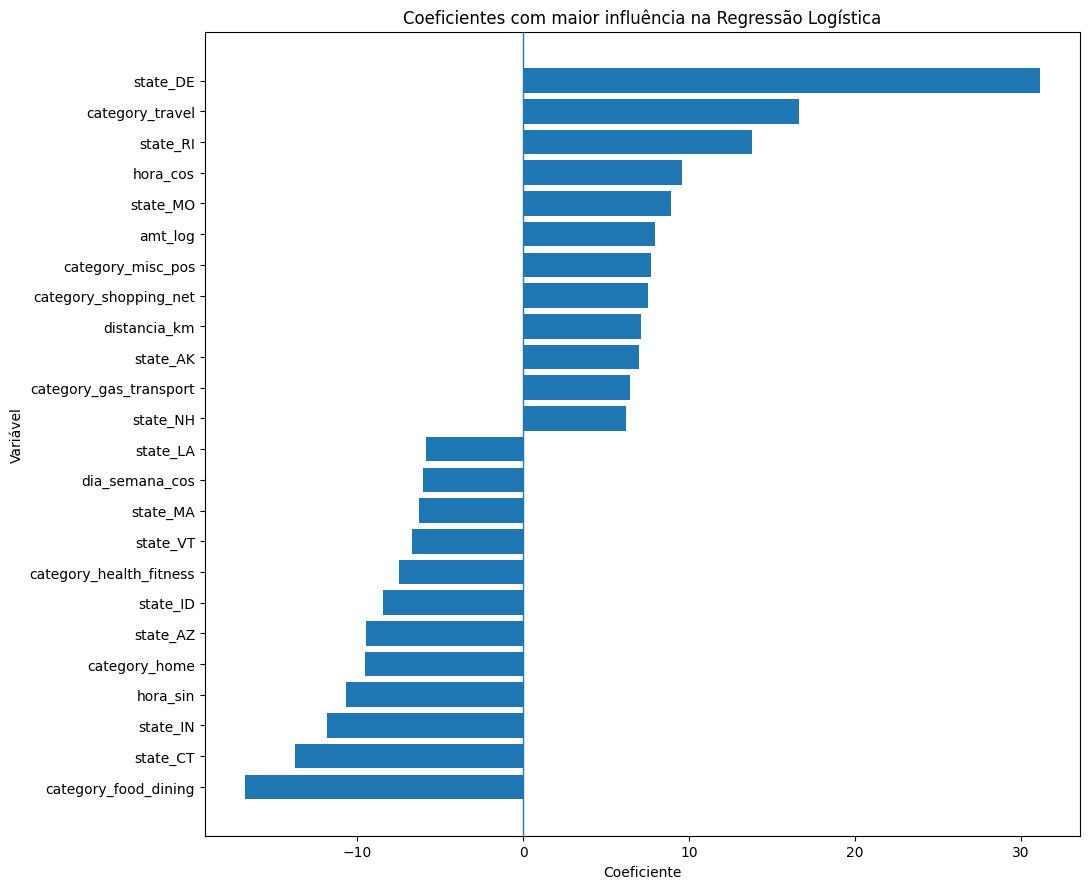

In [52]:
plt.figure(figsize=(11, 9))

plt.barh(
    coeficientes_plot["variavel"],
    coeficientes_plot["coeficiente"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Coeficientes com maior influência "
    "na Regressão Logística"
)

plt.xlabel("Coeficiente")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()